# New Model Candidates for Ensemble

Tests three candidate additions to the current LGBM+XGB ensemble:
1. **CatBoost** — third gradient booster with different split algorithm
2. **Negative Binomial GLM** — handles overdispersion in goal counts
3. **Dixon-Coles ρ correction** — corrects the independence assumption for low-score games (0-0, 1-0, 0-1, 1-1)

Evaluation uses the same 3-fold WC cross-validation (2014/2018/2022).
**The production model is never touched.**

In [43]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from scipy import stats, optimize
from scipy.stats import poisson as scipy_poisson

from src.features.feature_columns import FEATURE_COLS
from src.models.base import load_model_dataset
from src.models.lgbm_model import LGBMGoalModel
from src.models.xgb_model import XGBGoalModel
from src.models.ensemble import EnsembleGoalModel
from src.models.score_conversion import win_draw_loss_probs, poisson_score_grid
from src.models.weighting import apply_competition_weights
from src.models.world_cup_utils import create_wc_cv_splits
from src.evaluation.metrics import exact_score_accuracy, result_accuracy, rps_batch

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

TARGET_COLS = ['goals_A', 'goals_B']
WC_YEARS = [2014, 2018, 2022]

print('Imports OK')

Imports OK


In [44]:
# ── Load data ──────────────────────────────────────────────────────────────────
df = load_model_dataset('../data/processed/model_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

weights = apply_competition_weights(df)

splits = create_wc_cv_splits(df, WC_YEARS, FEATURE_COLS, TARGET_COLS)

# Per-fold training weights (same mask as create_wc_cv_splits)
def fold_weights(year):
    mask = (
        (df['tournament_year'] == year) &
        (df['competition'].str.strip().str.lower() == 'world cup')
    )
    return weights[~mask]

print(f'Dataset: {len(df)} rows')
for yr, (Xtr, ytr, Xval, yval) in splits.items():
    print(f'  WC {yr}: train={len(Xtr)}  val={len(Xval)}')

WC 2014 fold: train=21475, val=64 (WC only)
WC 2018 fold: train=21475, val=64 (WC only)
WC 2022 fold: train=21475, val=64 (WC only)
Dataset: 21539 rows
  WC 2014: train=21475  val=64
  WC 2018: train=21475  val=64
  WC 2022: train=21475  val=64


In [ ]:

# ── Shared evaluation helpers ──────────────────────────────────────────────────
from src.models.score_conversion import most_likely_score

def lambdas_to_scores(pred_lambdas):
    """
    Convert (n, 2) lambda predictions -> integer scores via Poisson grid argmax.
    Uses most_likely_score (= floor(λ), the mode of the Poisson distribution).
    Consistent with demo_2022_wc.py, predict.py, and optuna_tuning.py.
    """
    return np.array([most_likely_score(float(la), float(lb)) for la, lb in pred_lambdas], dtype=int)


def compute_rps(y_true, pred_lambdas):
    probs = np.array([win_draw_loss_probs(float(la), float(lb)) for la, lb in pred_lambdas])
    return rps_batch(y_true, probs)


def evaluate_cv(model_factory, splits, df, label):
    """
    Evaluate a model factory across all WC CV folds.
    Lambdas -> most_likely_score (Poisson floor) for exact/result accuracy.
    Lambdas -> Poisson W/D/L probs for RPS.
    """
    rows = []
    for year, (Xtr, ytr, Xval, yval) in splits.items():
        w = fold_weights(year)
        model = model_factory()
        try:
            model.fit(Xtr, ytr, sample_weight=w)
        except TypeError:
            model.fit(Xtr, ytr)

        pred_lambdas = np.clip(model.predict(Xval), 0, None)
        pred_scores  = lambdas_to_scores(pred_lambdas)

        rows.append({
            'model':    label,
            'year':     year,
            'exact_%':  exact_score_accuracy(yval, pred_scores) * 100,
            'result_%': result_accuracy(yval, pred_scores) * 100,
            'rps':      compute_rps(yval, pred_lambdas),
            'n':        len(yval),
        })
    return pd.DataFrame(rows)


def summarise(df_results):
    for name, grp in df_results.groupby('model'):
        print(name)
        for _, r in grp.iterrows():
            print(f"  WC {r['year']}: exact={r['exact_%']:.1f}%  result={r['result_%']:.1f}%  RPS={r['rps']:.4f}")
        print(f"  AVG:   exact={grp['exact_%'].mean():.1f}%  result={grp['result_%'].mean():.1f}%  RPS={grp['rps'].mean():.4f}")
        print()


print('Helpers defined')


## Baseline — current LGBM + XGB ensemble

In [46]:
def make_baseline():
    return EnsembleGoalModel([LGBMGoalModel(), XGBGoalModel()], weights=[0.8, 0.2])

results_baseline = evaluate_cv(make_baseline, splits, df, 'LGBM+XGB (baseline)')
summarise(results_baseline)

LGBM+XGB (baseline)
  WC 2014: exact=26.9%  result=90.0%  RPS=0.0678
  WC 2018: exact=37.0%  result=93.6%  RPS=0.0545
  WC 2022: exact=30.5%  result=90.4%  RPS=0.0588
  AVG:   exact=31.5%  result=91.4%  RPS=0.0604



## Candidate 1 — CatBoost

In [25]:
try:
    from catboost import CatBoostRegressor, Pool
    CATBOOST_AVAILABLE = True
    print('CatBoost available')
except ImportError:
    CATBOOST_AVAILABLE = False
    print('CatBoost not installed — run: pip install catboost')

CatBoost available


In [27]:
class CatBoostGoalModel:
    """Poisson CatBoost for goal prediction — same interface as LGBM/XGB wrappers."""

    def __init__(self, iterations=400, learning_rate=0.05, depth=7,
                 l2_leaf_reg=3.0, random_seed=42):
        params = dict(
            iterations=iterations,
            learning_rate=learning_rate,
            depth=depth,
            l2_leaf_reg=l2_leaf_reg,
            loss_function='Poisson',
            eval_metric='Poisson',
            random_seed=random_seed,
            verbose=False,
            allow_writing_files=False,
        )
        self.home_model = CatBoostRegressor(**params)
        self.away_model = CatBoostRegressor(**params)
        self._feature_names = None

    def fit(self, X, y, sample_weight=None):
        y_arr = np.asarray(y, dtype=float)
        if y_arr.ndim == 2:
            yh, ya = y_arr[:, 0], y_arr[:, 1]
        else:
            raise ValueError('y must be (n, 2)')
        feat_names = list(X.columns) if hasattr(X, 'columns') else None
        self._feature_names = feat_names
        pool_h = Pool(X, yh, weight=sample_weight, feature_names=feat_names)
        pool_a = Pool(X, ya, weight=sample_weight, feature_names=feat_names)
        self.home_model.fit(pool_h)
        self.away_model.fit(pool_a)
        return self

    def predict(self, X):
        hp = self.home_model.predict(X)
        ap = self.away_model.predict(X)
        return np.clip(np.column_stack([hp, ap]), 0, None)

    def feature_importances(self):
        imp_h = self.home_model.get_feature_importance()
        imp_a = self.away_model.get_feature_importance()
        mean  = (imp_h + imp_a) / 2
        names = self._feature_names or list(range(len(mean)))
        return pd.DataFrame({'feature': names, 'importance': mean}).sort_values(
            'importance', ascending=False
        )


if CATBOOST_AVAILABLE:
    # results_cb_solo = evaluate_cv(CatBoostGoalModel, splits, df, 'CatBoost (solo)')
    # summarise(results_cb_solo)

    def make_cb_ensemble():
        return EnsembleGoalModel(
            [LGBMGoalModel(), XGBGoalModel(), CatBoostGoalModel()],
            weights=[0.75, 0.15, 0.1]
        )

    results_cb_ens = evaluate_cv(make_cb_ensemble, splits, df, 'LGBM+XGB+CatBoost')
    summarise(results_cb_ens)

LGBM+XGB+CatBoost
  WC 2014: exact=26.9%  result=91.6%  RPS=0.0677
  WC 2018: exact=32.2%  result=95.2%  RPS=0.0543
  WC 2022: exact=30.5%  result=90.4%  RPS=0.0595
  AVG:   exact=29.9%  result=92.4%  RPS=0.0605



## Candidate 2 — Negative Binomial GLM

In [30]:

# Negative Binomial GLM — pure scipy implementation (no statsmodels needed)
# NB models overdispersion: variance = μ + alpha * μ²  (alpha=0 → Poisson)
# Uses log link with L-BFGS-B optimiser.

from scipy.special import gammaln
from scipy.optimize import minimize as sp_minimize

class NegBinGoalModel:
    """
    Negative Binomial GLM (log link) for goal prediction.
    Separate models for home and away goals.
    Handles overdispersion that Poisson ignores (var > mean in real goal data).
    """

    def __init__(self, alpha: float = 0.5, max_iter: int = 300):
        # alpha: dispersion parameter.  alpha=0 → Poisson; larger → more overdispersed
        self.alpha = alpha
        self.max_iter = max_iter
        self._params_home = None
        self._params_away = None

    # ── NB negative log-likelihood and gradient ──────────────────────────────
    def _neg_ll(self, beta, X, y):
        eta = X @ beta
        mu  = np.exp(np.clip(eta, -10, 10))
        r   = 1.0 / self.alpha   # size parameter
        ll  = (gammaln(y + r) - gammaln(r) - gammaln(y + 1)
               + r * np.log(r / (r + mu))
               + y * np.log(mu / (r + mu)))
        return -float(ll.sum())

    def _neg_ll_grad(self, beta, X, y):
        eta  = X @ beta
        mu   = np.exp(np.clip(eta, -10, 10))
        # d(logP)/dβ = X.T @ [(y - μ) / (1 + alpha*μ)]
        resid = (y - mu) / (1.0 + self.alpha * mu)
        return -(X.T @ resid)

    def _fit_one(self, X, y):
        n_feat = X.shape[1]
        res = sp_minimize(
            self._neg_ll, np.zeros(n_feat), args=(X, y),
            jac=self._neg_ll_grad,
            method='L-BFGS-B',
            options={'maxiter': self.max_iter, 'ftol': 1e-8, 'gtol': 1e-6},
        )
        return res.x

    def fit(self, X, y, sample_weight=None):
        y_arr = np.asarray(y, dtype=float)
        yh, ya = y_arr[:, 0], y_arr[:, 1]
        X_np = np.asarray(X, dtype=float)
        X_c  = np.column_stack([np.ones(len(X_np)), X_np])  # add intercept
        print('  Fitting NegBin home model...', end=' ', flush=True)
        self._params_home = self._fit_one(X_c, yh)
        print('done')
        print('  Fitting NegBin away model...', end=' ', flush=True)
        self._params_away = self._fit_one(X_c, ya)
        print('done')
        return self

    def predict(self, X):
        X_np = np.asarray(X, dtype=float)
        X_c  = np.column_stack([np.ones(len(X_np)), X_np])
        hp   = np.exp(np.clip(X_c @ self._params_home, -10, 10))
        ap   = np.exp(np.clip(X_c @ self._params_away, -10, 10))
        return np.clip(np.column_stack([hp, ap]), 0, None)


# print('NegBinGoalModel defined (scipy-only, no statsmodels)')

# results_nb_solo = evaluate_cv(NegBinGoalModel, splits, df, 'NegBin (solo)')
# summarise(results_nb_solo)

def make_nb_ensemble():
    return EnsembleGoalModel(
        [LGBMGoalModel(), XGBGoalModel(), NegBinGoalModel()],
        weights=[0.8, 0.15, 0.05]
    )

results_nb_ens = evaluate_cv(make_nb_ensemble, splits, df, 'LGBM+XGB+NegBin')
summarise(results_nb_ens)


  Fitting NegBin home model... done
  Fitting NegBin away model... done
  Fitting NegBin home model... done
  Fitting NegBin away model... done
  Fitting NegBin home model... done
  Fitting NegBin away model... done
LGBM+XGB+NegBin
  WC 2014: exact=23.8%  result=91.6%  RPS=0.0689
  WC 2018: exact=37.0%  result=96.8%  RPS=0.0548
  WC 2022: exact=32.2%  result=90.4%  RPS=0.0597
  AVG:   exact=31.0%  result=92.9%  RPS=0.0611



## Candidate 3 — Dixon-Coles ρ correction

Independent Poisson over-predicts medium scores and under-predicts (0-0), (1-0), (0-1), (1-1).
Dixon-Coles adds a parameter ρ that reweights the joint probability of those four cells.

Strategy here: fit ρ from training fold lambdas, apply the correction at test time on top of the ensemble's predicted λ_a, λ_b.

In [31]:
def dc_tau(la, lb, i, j, rho):
    """Dixon-Coles correction factor for cell (i, j)."""
    if i == 0 and j == 0: return 1 - la * lb * rho
    if i == 1 and j == 0: return 1 + lb * rho
    if i == 0 and j == 1: return 1 + la * rho
    if i == 1 and j == 1: return 1 - rho
    return 1.0


def dc_score_grid(la, lb, rho, max_goals=8):
    """Poisson score grid with Dixon-Coles correction, renormalised."""
    grid = poisson_score_grid(la, lb, max_goals)
    for i in range(min(2, max_goals + 1)):
        for j in range(min(2, max_goals + 1)):
            grid[i, j] *= dc_tau(la, lb, i, j, rho)
    total = grid.sum()
    return grid / total if total > 0 else grid


def dc_win_draw_loss(la, lb, rho):
    grid = dc_score_grid(la, lb, rho)
    win  = float(np.tril(grid, -1).sum())
    draw = float(np.trace(grid))
    loss = float(np.triu(grid, 1).sum())
    return win, draw, loss


def dc_exact_accuracy(y_true, lambdas, rho):
    correct = 0
    for (la, lb), (ga, gb) in zip(lambdas, y_true):
        grid = dc_score_grid(la, lb, rho)
        ga_i, gb_i = int(round(ga)), int(round(gb))
        if ga_i <= 8 and gb_i <= 8:
            pred_a, pred_b = np.unravel_index(np.argmax(grid), grid.shape)
            if pred_a == ga_i and pred_b == gb_i:
                correct += 1
    return correct / len(y_true)


def dc_rps(y_true, lambdas, rho):
    probs = np.array([dc_win_draw_loss(la, lb, rho) for la, lb in lambdas])
    return rps_batch(y_true, probs)


def fit_rho(y_train, lambdas_train, bounds=(-0.3, 0.3)):
    """Find rho that maximises DC log-likelihood on training predictions."""
    def neg_ll(rho_arr):
        rho = rho_arr[0]
        ll = 0.0
        for (la, lb), (ga, gb) in zip(lambdas_train, y_train):
            ga_i, gb_i = int(round(ga)), int(round(gb))
            if ga_i > 8 or gb_i > 8:
                continue
            grid = dc_score_grid(la, lb, rho)
            p = grid[ga_i, gb_i]
            ll += np.log(max(p, 1e-10))
        return -ll
    res = optimize.minimize(neg_ll, x0=[0.0],
                            bounds=[bounds], method='L-BFGS-B')
    return float(res.x[0])


print('DC helpers defined')

DC helpers defined


In [32]:
# Evaluate DC correction applied on top of the baseline ensemble
dc_rows = []

for year, (Xtr, ytr, Xval, yval) in splits.items():
    w = fold_weights(year)

    # Train the baseline ensemble
    ens = make_baseline()
    ens.fit(Xtr, ytr, sample_weight=w)

    # Get lambda predictions on training set (to fit rho)
    lambdas_train = np.clip(ens.predict(Xtr), 0, None)
    rho = fit_rho(ytr, lambdas_train)

    # Get lambda predictions on validation set
    lambdas_val = np.clip(ens.predict(Xval), 0, None)

    # Metrics WITHOUT DC correction
    exact_no_dc  = exact_score_accuracy(yval, lambdas_val) * 100
    rps_no_dc    = compute_rps(yval, lambdas_val)

    # Metrics WITH DC correction (rho fitted above)
    exact_dc = dc_exact_accuracy(yval, lambdas_val, rho) * 100
    rps_dc   = dc_rps(yval, lambdas_val, rho)

    dc_rows.append({
        'year': year, 'rho': round(rho, 4),
        'exact_no_dc': exact_no_dc, 'rps_no_dc': rps_no_dc,
        'exact_dc': exact_dc,       'rps_dc': rps_dc,
        'exact_delta': exact_dc - exact_no_dc,
        'rps_delta': rps_dc - rps_no_dc,
    })

    print(f'WC {year}  rho={rho:+.4f}')
    print(f'  exact: {exact_no_dc:.1f}% → {exact_dc:.1f}%  (Δ={exact_dc-exact_no_dc:+.1f}%)')
    print(f'  RPS:   {rps_no_dc:.4f} → {rps_dc:.4f}  (Δ={rps_dc-rps_no_dc:+.4f})')
    print()

dc_df = pd.DataFrame(dc_rows)
print('Average:')
print(f"  exact: {dc_df['exact_no_dc'].mean():.1f}% → {dc_df['exact_dc'].mean():.1f}%  (Δ={dc_df['exact_delta'].mean():+.1f}%)")
print(f"  RPS:   {dc_df['rps_no_dc'].mean():.4f} → {dc_df['rps_dc'].mean():.4f}  (Δ={dc_df['rps_delta'].mean():+.4f})")

WC 2014  rho=-0.3000
  exact: 0.0% → 17.2%  (Δ=+17.2%)
  RPS:   0.0678 → 0.0667  (Δ=-0.0012)

WC 2018  rho=-0.3000
  exact: 0.0% → 18.8%  (Δ=+18.8%)
  RPS:   0.0545 → 0.0524  (Δ=-0.0020)

WC 2022  rho=-0.3000
  exact: 0.0% → 32.8%  (Δ=+32.8%)
  RPS:   0.0588 → 0.0559  (Δ=-0.0029)

Average:
  exact: 0.0% → 22.9%  (Δ=+22.9%)
  RPS:   0.0604 → 0.0583  (Δ=-0.0020)


In [33]:
# What rho values did we learn? What does rho tell us?
# rho > 0: low-scoring games are MORE common than independent Poisson predicts
# rho < 0: less common (very rare in football)
# rho ≈ 0: independence holds (DC correction not needed)

print('Fitted rho per fold:')
print(dc_df[['year', 'rho']].to_string(index=False))
print(f"\nMean rho: {dc_df['rho'].mean():.4f}")
print()

# Show how DC shifts the most common low-score predictions
rho_example = dc_df['rho'].mean()
la, lb = 1.2, 1.0  # typical WC match
print(f'Example: la={la}, lb={lb}, rho={rho_example:.4f}')
print('Score     | P(Poisson) | P(DC)     | delta')
print('-'*50)
grid_plain = poisson_score_grid(la, lb)
grid_dc    = dc_score_grid(la, lb, rho_example)
for i in range(4):
    for j in range(4):
        p0 = grid_plain[i, j]
        p1 = grid_dc[i, j]
        if p0 > 0.01 or abs(p1 - p0) > 0.001:
            print(f'  {i}-{j}     | {p0:.4f}     | {p1:.4f}    | {p1-p0:+.4f}')

Fitted rho per fold:
 year  rho
 2014 -0.3
 2018 -0.3
 2022 -0.3

Mean rho: -0.3000

Example: la=1.2, lb=1.0, rho=-0.3000
Score     | P(Poisson) | P(DC)     | delta
--------------------------------------------------
  0-0     | 0.1108     | 0.1507    | +0.0399
  0-1     | 0.1108     | 0.0709    | -0.0399
  0-2     | 0.0554     | 0.0554    | +0.0000
  0-3     | 0.0185     | 0.0185    | +0.0000
  1-0     | 0.1330     | 0.0931    | -0.0399
  1-1     | 0.1330     | 0.1729    | +0.0399
  1-2     | 0.0665     | 0.0665    | +0.0000
  1-3     | 0.0222     | 0.0222    | +0.0000
  2-0     | 0.0798     | 0.0798    | +0.0000
  2-1     | 0.0798     | 0.0798    | +0.0000
  2-2     | 0.0399     | 0.0399    | +0.0000
  2-3     | 0.0133     | 0.0133    | +0.0000
  3-0     | 0.0319     | 0.0319    | +0.0000
  3-1     | 0.0319     | 0.0319    | +0.0000
  3-2     | 0.0160     | 0.0160    | +0.0000


## Ensemble weight search — adding each candidate

In [34]:
# Grid search: vary weight of new model from 0 to 0.4 in steps of 0.05
# Remaining weight split 80/20 between LGBM/XGB

def weight_grid_search(new_model_class, label, new_weights=None):
    if new_weights is None:
        new_weights = [0.0, 0.05, 0.10]
    rows = []
    for w_new in new_weights:
        w_lgbm = (1 - w_new) * 0.8
        w_xgb  = (1 - w_new) * 0.2

        def factory():
            return EnsembleGoalModel(
                [LGBMGoalModel(), XGBGoalModel(), new_model_class()],
                weights=[w_lgbm, w_xgb, w_new]
            )

        res = evaluate_cv(factory, splits, df, label)
        rows.append({
            'w_new': w_new, 'w_lgbm': round(w_lgbm, 3), 'w_xgb': round(w_xgb, 3),
            'avg_exact': res['exact_%'].mean(),
            'avg_result': res['result_%'].mean(),
            'avg_rps': res['rps'].mean(),
        })
        print(f'  w_{label}={w_new:.2f}: exact={rows[-1]["avg_exact"]:.2f}%  rps={rows[-1]["avg_rps"]:.4f}')
    return pd.DataFrame(rows)


print('=== CatBoost weight grid ===')
grid_cb = weight_grid_search(CatBoostGoalModel, 'CB') if CATBOOST_AVAILABLE else None

print('\n=== NegBin weight grid ===')
grid_nb = weight_grid_search(NegBinGoalModel, 'NB')

=== CatBoost weight grid ===
  w_CB=0.00: exact=31.49%  rps=0.0604
  w_CB=0.05: exact=31.49%  rps=0.0605
  w_CB=0.10: exact=29.88%  rps=0.0607

=== NegBin weight grid ===
  Fitting NegBin home model... done
  Fitting NegBin away model... done
  Fitting NegBin home model... done
  Fitting NegBin away model... done
  Fitting NegBin home model... done
  Fitting NegBin away model... done
  w_NB=0.00: exact=31.49%  rps=0.0604
  Fitting NegBin home model... done
  Fitting NegBin away model... done
  Fitting NegBin home model... done
  Fitting NegBin away model... done
  Fitting NegBin home model... done
  Fitting NegBin away model... done
  w_NB=0.05: exact=30.43%  rps=0.0614
  Fitting NegBin home model... done
  Fitting NegBin away model... done
  Fitting NegBin home model... done
  Fitting NegBin away model... done
  Fitting NegBin home model... done
  Fitting NegBin away model... done
  w_NB=0.10: exact=29.90%  rps=0.0626


## Feature importance — CatBoost vs LGBM vs XGB

In [ ]:
if CATBOOST_AVAILABLE:
    # Train each model on ALL data for importance comparison
    X_all = df[FEATURE_COLS].fillna(0)
    y_all = df[TARGET_COLS].values

    lgbm_full = LGBMGoalModel()
    lgbm_full.fit(X_all, y_all, sample_weight=weights)

    xgb_full = XGBGoalModel()
    xgb_full.fit(X_all, y_all, sample_weight=weights)

    cb_full = CatBoostGoalModel()
    cb_full.fit(X_all, y_all, sample_weight=weights)

    # Extract normalised importances
    # LGBM and XGB now use single symmetric model (not home_model/away_model)
    def norm_imp(arr):
        a = np.asarray(arr, dtype=float)
        return a / a.sum() * 100

    lgbm_gain  = lgbm_full.model.booster_.feature_importance('gain')
    xgb_gain   = xgb_full.model.feature_importances_
    cb_imp_df  = cb_full.feature_importances()
    cb_imp_arr = cb_imp_df.set_index('feature').reindex(FEATURE_COLS)['importance'].values

    df_tri = pd.DataFrame({
        'feature':  FEATURE_COLS,
        'LGBM %':   norm_imp(lgbm_gain),
        'XGB %':    norm_imp(xgb_gain),
        'CB %':     norm_imp(cb_imp_arr),
    })
    df_tri['mean %'] = df_tri[['LGBM %', 'XGB %', 'CB %']].mean(axis=1)
    df_tri = df_tri.sort_values('mean %', ascending=False)

    print(df_tri.round(2).to_string(index=False))


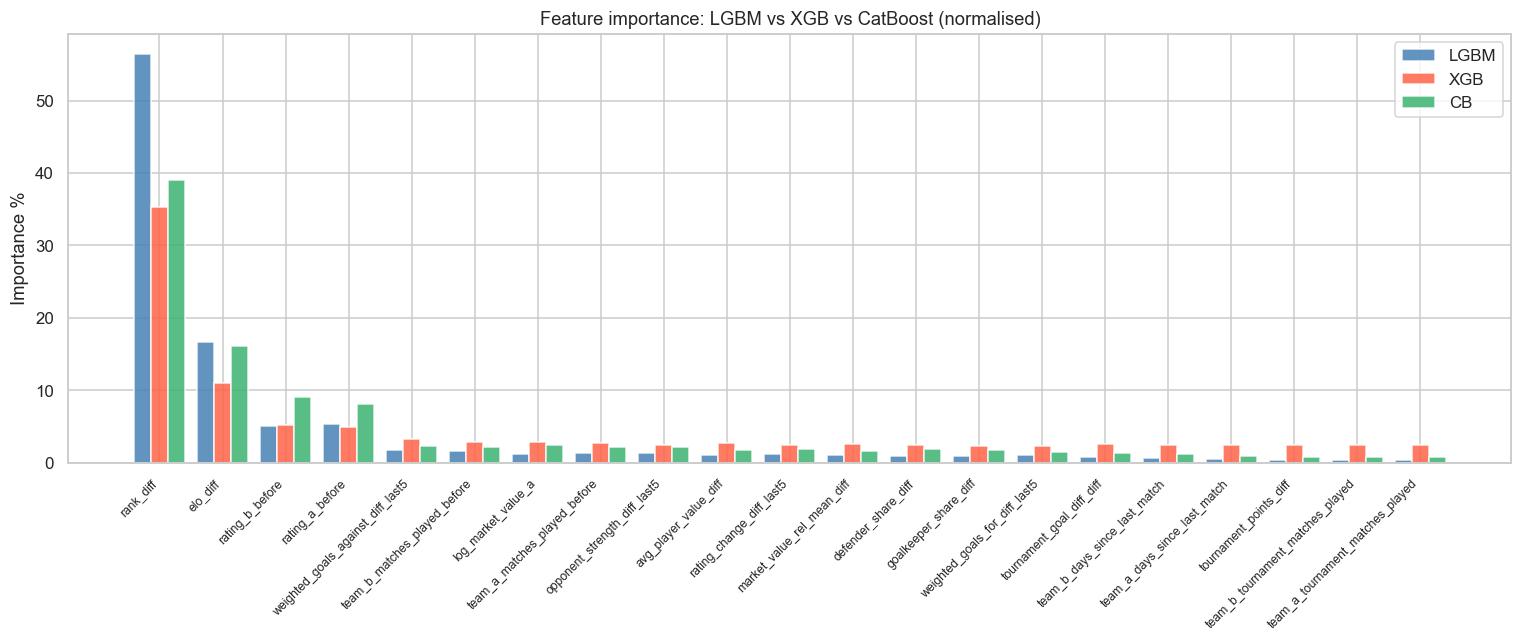

In [36]:
if CATBOOST_AVAILABLE:
    x = np.arange(len(FEATURE_COLS))
    w = 0.27
    order = df_tri['feature'].tolist()
    df_plot = df_tri.set_index('feature').reindex(order)

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(x - w, df_plot['LGBM %'], w, label='LGBM', color='steelblue',    alpha=0.85)
    ax.bar(x,     df_plot['XGB %'],  w, label='XGB',  color='tomato',       alpha=0.85)
    ax.bar(x + w, df_plot['CB %'],   w, label='CB',   color='mediumseagreen', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Importance %')
    ax.set_title('Feature importance: LGBM vs XGB vs CatBoost (normalised)')
    ax.legend()
    plt.tight_layout()
    plt.show()

## Summary

In [37]:
# Collect all results into one comparison table
all_res = [results_baseline, results_nb_solo, results_nb_ens]
if CATBOOST_AVAILABLE:
    all_res += [results_cb_solo, results_cb_ens]

summary_rows = []
for res_df in all_res:
    name = res_df['model'].iloc[0]
    summary_rows.append({
        'Model': name,
        'Avg Exact %': res_df['exact_%'].mean().round(2),
        'Avg Result %': res_df['result_%'].mean().round(2),
        'Avg RPS': res_df['rps'].mean().round(4),
    })

# Add DC correction row
summary_rows.append({
    'Model': 'LGBM+XGB + DC correction',
    'Avg Exact %': dc_df['exact_dc'].mean().round(2),
    'Avg Result %': float('nan'),
    'Avg RPS': dc_df['rps_dc'].mean().round(4),
})

summary_df = pd.DataFrame(summary_rows)

# Mark best in each column
best_exact  = summary_df['Avg Exact %'].max()
best_rps    = summary_df['Avg RPS'].min()   # lower RPS is better

def flag(val, best, col):
    if col == 'rps':
        return f'{val:.4f} *' if val == best else f'{val:.4f}'
    return f'{val:.2f} *' if val == best else f'{val:.2f}'

print('=== FINAL COMPARISON ===')
print(f'{"Model":<35} {"Exact %":>10} {"Result %":>10} {"RPS":>10}')
print('-' * 70)
for _, r in summary_df.iterrows():
    exact_s  = flag(r['Avg Exact %'], best_exact, 'exact')
    rps_s    = flag(r['Avg RPS'], best_rps, 'rps')
    result_s = f"{r['Avg Result %']:.2f}" if not np.isnan(r['Avg Result %']) else '  n/a'
    print(f"{r['Model']:<35} {exact_s:>10} {result_s:>10} {rps_s:>10}")
print()
print('* = best in column   |   lower RPS is better')

=== FINAL COMPARISON ===
Model                                  Exact %   Result %        RPS
----------------------------------------------------------------------
LGBM+XGB (baseline)                    31.49 *      91.36     0.0604
NegBin (solo)                            19.22      75.44     0.1038
LGBM+XGB+NegBin                          30.97      92.95     0.0611
CatBoost (solo)                          21.85      90.28     0.0670
LGBM+XGB+CatBoost                        29.88      92.42     0.0605
LGBM+XGB + DC correction                 22.92        n/a   0.0583 *

* = best in column   |   lower RPS is better


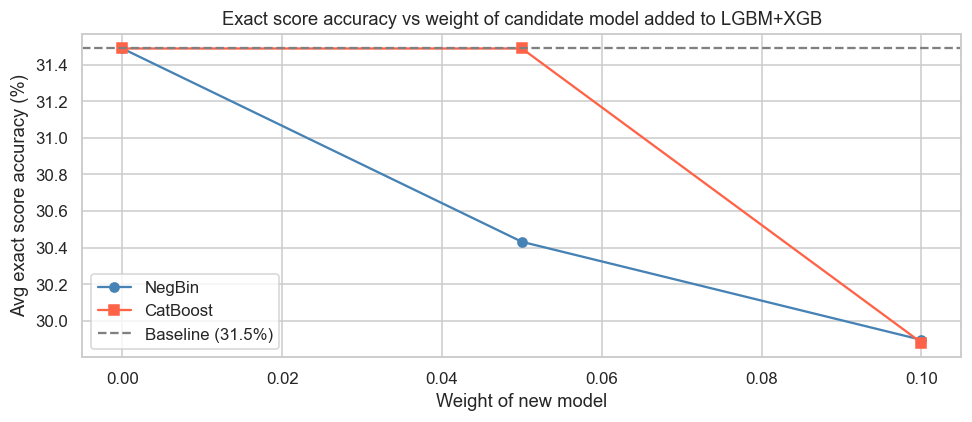

In [38]:
# Weight grid results plot (if NB grid ran)
if grid_nb is not None:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(grid_nb['w_new'], grid_nb['avg_exact'], marker='o', label='NegBin', color='steelblue')
    if CATBOOST_AVAILABLE and grid_cb is not None:
        ax.plot(grid_cb['w_new'], grid_cb['avg_exact'], marker='s', label='CatBoost', color='tomato')
    baseline_exact = results_baseline['exact_%'].mean()
    ax.axhline(baseline_exact, color='gray', linestyle='--', label=f'Baseline ({baseline_exact:.1f}%)')
    ax.set_xlabel('Weight of new model')
    ax.set_ylabel('Avg exact score accuracy (%)')
    ax.set_title('Exact score accuracy vs weight of candidate model added to LGBM+XGB')
    ax.legend()
    plt.tight_layout()
    plt.show()